# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [75]:
file_path = '../data/raw/vgsales.csv'
df = pd.read_csv(file_path)

## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [76]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [77]:
df.info()
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB

Número de filas: 16598
Número de columnas: 11


## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [78]:
# Numerical variables
display(df.describe())

# Años que más juegos tiene el data set
df['Year'].value_counts().head()


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Year
2009.0    1431
2008.0    1428
2010.0    1259
2007.0    1202
2011.0    1139
Name: count, dtype: int64

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [ ]:
df_clean = df.copy()
# Null values
print(f"Nulos:\n{df.isnull().sum()}")

df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['Year'])
df['Year'] = df_clean['Year'].astype(int)

print(f"\nNulos despues de la limpieza:\n{df_clean.isnull().sum()}")

Nulos:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Nulos despues de la limpieza:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [107]:
# Duplicated rows
print("\nDuplicados totales: ",df.duplicated().sum())
print("Videojuegos duplicados (nombre): ")
display(df[df['Name'].duplicated(keep=False)].sort_values('Name').head(8))

df_clean = df.copy().groupby('Name', as_index=False).agg({
    'Platform': lambda x: ', '.join(sorted(x.unique())),
    'Genre': 'first',
    'Publisher': 'first',
    'Year': 'first',
    'NA_Sales': 'sum',
    'EU_Sales': 'sum',
    'JP_Sales': 'sum',
    'Other_Sales': 'sum',
    'Global_Sales': 'sum'
})

if df_clean['Name'].duplicated(keep=False).any():
    print("Queda algún juego duplicado")
else:
    print("No queda ningún juego duplicado")
# display(df_clean.sort_values('Name').head(20))


Duplicados totales:  0
Videojuegos duplicados (nombre): 


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1739,1741,007: Quantum of Solace,PS3,2008.0,Action,Activision,0.43,0.52,0.02,0.20,1.16
9318,9320,007: Quantum of Solace,DS,2008.0,Action,Activision,0.11,0.01,0.00,0.01,0.14
14547,14550,007: Quantum of Solace,PC,2008.0,Action,Activision,0.01,0.01,0.00,0.00,0.03
1273,1275,007: Quantum of Solace,X360,2008.0,Action,Activision,0.82,0.52,0.01,0.14,1.49
4499,4501,007: Quantum of Solace,PS2,2008.0,Action,Activision,0.17,0.00,0.00,0.26,0.43
3038,3040,007: Quantum of Solace,Wii,2008.0,Action,Activision,0.30,0.29,0.01,0.07,0.67
2247,2249,007: The World is not Enough,PS,2000.0,Action,Electronic Arts,0.51,0.35,0.00,0.06,0.92
1200,1202,007: The World is not Enough,N64,2000.0,Action,Electronic Arts,1.13,0.38,0.02,0.03,1.55


No queda ningún juego duplicado


In [97]:
# Comprovaciones finales
print(f"Número de filas al inicio: {df.shape[0]} --> Al final {df_clean.shape[0]}")

Número de filas al inicio: 16598 --> Al final 11493


## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

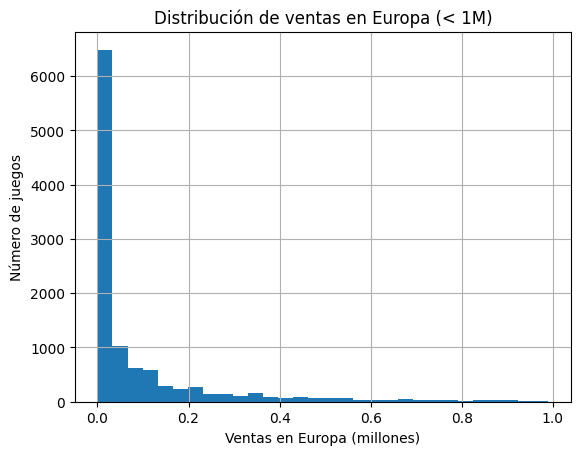

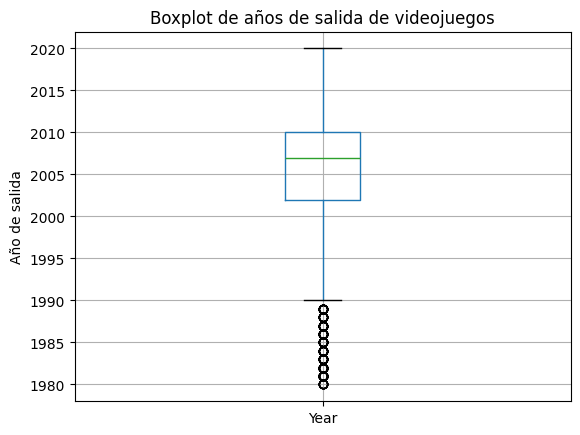

In [185]:
# Histogram

df_clean[df_clean['EU_Sales'] < 1]['EU_Sales'].hist(bins=30)

plt.title('Distribución de ventas en Europa (< 1M)')
plt.xlabel('Ventas en Europa (millones)')
plt.ylabel('Número de juegos')
plt.show()

# Boxplot

df_clean.boxplot(column='Year')

plt.title('Boxplot de años de salida de videojuegos')
plt.ylabel('Año de salida')
plt.show()

Las ventas en Europa presentan una distribución fuertemente sesgada, donde la mayoría de los juegos tienen ventas muy bajas, donde más de la mitad de los datos totales no llegan a medio millón de ingreso y solo unos pocos títulos concentran grandes valores.

Esto indica una distribución típica de mercado, donde unos pocos productos dominan el rendimiento total de la industria.

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

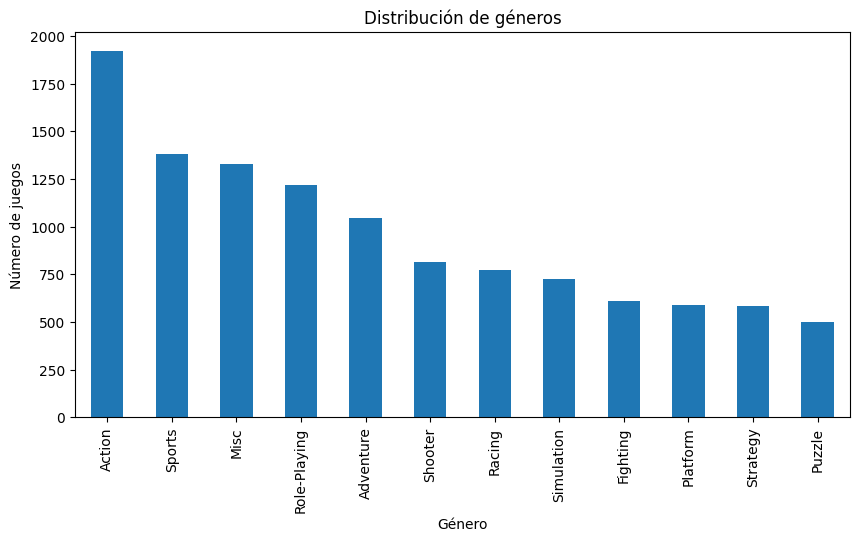

In [197]:
# Bar plot for a categorical variable
plt.figure(figsize=(10,5))
df_clean['Genre'].value_counts().plot(kind='bar')

plt.title('Distribución de géneros')
plt.xlabel('Género')
plt.ylabel('Número de juegos')
plt.show()

## 9. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

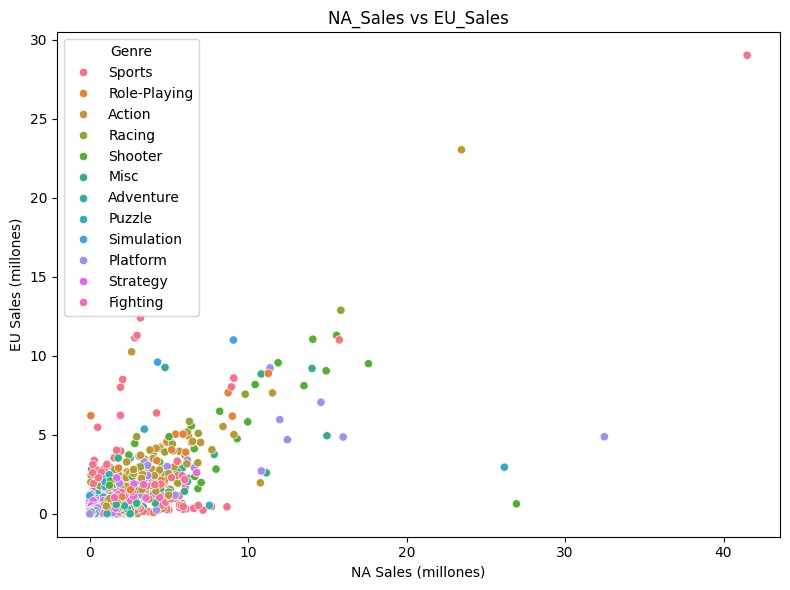

Platform,2600,3DS,DC,DS,GB,GBA,GC,GEN,N64,NES,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Genre,,,,,,,,,,,,,,,,,,,,,
Action,28,55,8,222,16,103,65,4,45,13,...,23,0,29,0,1,158,19,190,90,23
Adventure,11,22,5,110,9,60,27,2,39,10,...,18,1,24,0,0,82,9,94,52,16
Fighting,4,17,0,66,8,22,24,0,8,6,...,9,0,20,0,0,47,11,53,31,8
Misc,10,40,6,159,7,63,50,1,28,14,...,16,0,19,0,0,110,14,126,65,17
Platform,8,14,2,79,5,27,16,1,14,2,...,3,0,10,0,0,60,6,60,30,7
Puzzle,1,14,2,65,2,15,20,0,14,3,...,6,0,9,0,0,46,3,33,22,11
Racing,14,21,2,82,9,41,28,1,15,6,...,3,1,18,1,2,62,4,80,57,10
Role-Playing,14,35,5,115,8,56,47,1,32,9,...,11,0,20,0,1,110,7,111,60,15
Shooter,7,16,4,84,10,35,22,2,21,9,...,4,0,10,0,0,78,7,72,33,12


In [212]:
# Scatterplot

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean,
                x='NA_Sales', 
                y='EU_Sales', 
                hue='Genre')
plt.title('NA_Sales vs EU_Sales')
plt.xlabel('NA Sales (millones)')
plt.ylabel('EU Sales (millones)')
plt.tight_layout()
plt.show()


# Crosstab for two categorical variables   
# pd.crosstab(df['categorical_column1'], df['categorical_column2'])
pd.crosstab(df_clean['Genre'], df['Platform'])


## 10. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

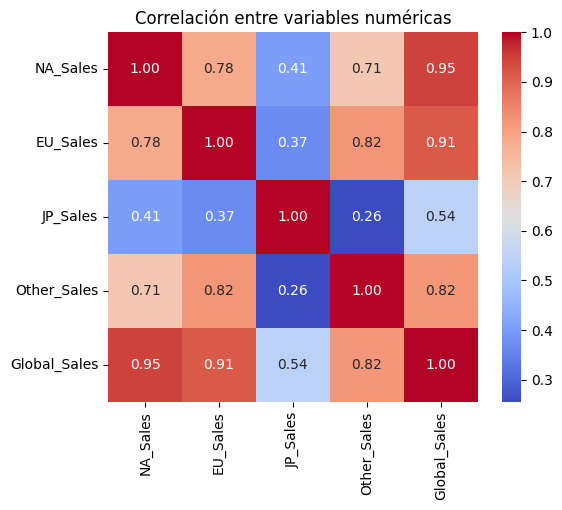

In [217]:
# Correlation matrix
corr = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlación entre variables numéricas')
plt.show()